# Fault Tree Analysis of Autonomous Vehicle Stopping Failure

This notebook performs Fault Tree Analysis for an autonomous vehicle safety case.

The top event is:

**Autonomous vehicle does not stop in time**

The model includes:

- Camera and perception failures
- LiDAR and radar sensor failures
- Object classification error
- Braking control failures
- Communication delay
- Brake pressure sensor fault

The notebook uses:

1. `pfta` library for model definition
2. A custom Python FTA engine for probability calculation, gate analysis, cut sets, and visualization

In [1]:
# Install required Python libraries
!pip install pfta graphviz pandas

# Install system Graphviz package for diagram rendering in Google Colab
!apt-get install -y graphviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.7 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


## Import Required Libraries

This block imports the required libraries.

- `pfta` is used to create the fault tree from text.
- `dataclass` is used to create simple node classes.
- `field` creates safe default child lists.
- `product` creates cut set combinations.
- `pandas` creates tables.
- `graphviz` draws the fault tree.
- `IPython.display` displays images and tables in Colab.

In [2]:
# Import PFTA FaultTree class
from pfta.core import FaultTree as PFTATree

# Import dataclass tools for creating simple node structures
from dataclasses import dataclass, field

# Import product for cut set combinations
from itertools import product

# Import pandas for result tables
import pandas as pd

# Import Graphviz for fault tree visualization
from graphviz import Digraph

# Import display tools for Jupyter Notebook / Google Colab
from IPython.display import Image, display

## Define the Fault Tree Using PFTA Text Format

This block defines the autonomous vehicle fault tree using PFTA text format.

The basic events are A to J.

The gates are G1 to G6 and TOP.

The top event is:

**Autonomous vehicle does not stop in time**

In [3]:
# Define the fault tree in PFTA text format
fta_text = """
- time_unit: hour
- times: 1

Event: A
- label: Front camera fails
- model_type: Fixed
- probability: 0.04
- intensity: 0

Event: B
- label: Obstacle detection software error
- model_type: Fixed
- probability: 0.035
- intensity: 0

Event: C
- label: Brake actuator fails
- model_type: Fixed
- probability: 0.03
- intensity: 0

Event: D
- label: Speed control module fails
- model_type: Fixed
- probability: 0.025
- intensity: 0

Event: E
- label: LiDAR sensor unavailable
- model_type: Fixed
- probability: 0.03
- intensity: 0

Event: F
- label: Radar sensor signal loss
- model_type: Fixed
- probability: 0.025
- intensity: 0

Event: G
- label: Object classification model error
- model_type: Fixed
- probability: 0.02
- intensity: 0

Event: H
- label: Emergency braking command not issued
- model_type: Fixed
- probability: 0.018
- intensity: 0

Event: I
- label: CAN bus communication delay
- model_type: Fixed
- probability: 0.015
- intensity: 0

Event: J
- label: Brake pressure sensor fault
- model_type: Fixed
- probability: 0.012
- intensity: 0

Gate: G1
- label: Vision perception failure
- type: OR
- inputs: A, B

Gate: G2
- label: Sensor perception failure
- type: OR
- inputs: E, F

Gate: G3
- label: Obstacle not detected
- type: OR
- inputs: G1, G2, G

Gate: G4
- label: Braking control failure
- type: OR
- inputs: C, D

Gate: G5
- label: Braking command failure
- type: OR
- inputs: H, I

Gate: G6
- label: Braking system unavailable
- type: OR
- inputs: G4, G5, J

Gate: TOP
- label: Autonomous vehicle does not stop in time
- type: OR
- inputs: G3, G6
"""

# Create PFTA model from the text definition
pfta_model = PFTATree(fta_text)

# Confirm that the PFTA model was created
print("PFTA model created successfully.")

PFTA model created successfully.


##  Create the Node Class

This block creates a simple `Node` class.

Each node represents either:

- A basic event
- A logic gate

Each node stores:

- Name
- Type
- Probability
- Child nodes

In [4]:
# Create a node class for basic events and gates
@dataclass
class Node:

    # Name of event or gate
    name: str

    # Type of node: BASIC, OR, AND, XOR, PAND, or INHIBIT
    kind: str

    # Probability for basic events
    p: float = None

    # Child nodes for gates
    children: list = field(default_factory=list)

##  Helper Functions

This block defines helper functions used by the custom FTA engine.

The helper functions:

- Format probability values
- Multiply values
- Calculate gate output probability
- Remove non-minimal cut sets

In [5]:
# Format probability values neatly
def fmt(x):

    # Keep five decimal places and remove unnecessary zeros
    return f"{x:.5f}".rstrip("0").rstrip(".")


# Helper function to multiply values
def product_value(values):

    # Start multiplication from 1
    r = 1

    # Multiply each value in the list or generator
    for v in values:
        r *= v

    # Return final product
    return r


# Calculate gate output probability
def gate(kind, ps):

    # AND, PAND, and INHIBIT gates are treated as multiplication in this simple model
    if kind in ["AND", "PAND", "INHIBIT"]:

        # Start with 1 for multiplication
        r = 1

        # Multiply all input probabilities
        for p in ps:
            r *= p

        # Return final result
        return r

    # OR gate probability calculation
    if kind == "OR":

        # Start with 1 for multiplication of complements
        r = 1

        # Multiply the probability that each input does not occur
        for p in ps:
            r *= (1 - p)

        # Return probability that at least one input occurs
        return 1 - r

    # XOR means exactly one input occurs
    if kind == "XOR":

        # Calculate probability that only one input occurs
        return sum(
            p * product_value(1 - q for j, q in enumerate(ps) if j != i)
            for i, p in enumerate(ps)
        )

    # Raise error for unsupported gate type
    raise ValueError("Unsupported gate type")


# Remove non-minimal cut sets
def minimize(cutsets):

    # Remove duplicate cut sets and sort by size
    unique = sorted(
        set(frozenset(c) for c in cutsets),
        key=lambda x: (len(x), sorted(x))
    )

    # Store minimal cut sets
    minimal = []

    # Check every cut set
    for c in unique:

        # Keep cut set only if no smaller cut set already covers it
        if not any(m.issubset(c) for m in minimal):
            minimal.append(c)

    # Convert frozensets back to normal sets
    return [set(c) for c in minimal]

## Create the Custom FTA Class

This class performs the main fault tree analysis.

It can:

1. Evaluate all node probabilities
2. Collect all nodes
3. Create a probability table
4. Create a gate-by-gate analysis table
5. Generate minimal cut sets
6. Draw the fault tree diagram

In [6]:
# Fault Tree Analysis class
class FTA:

    # Store the top event
    def __init__(self, top):
        self.top = top

    # Evaluate all node probabilities
    def evaluate(self):

        # Store probabilities for every node
        probs = {}

        # Recursive solver function
        def solve(n):

            # If node is a basic event, return its probability directly
            if n.kind == "BASIC":
                probs[n.name] = n.p
                return n.p

            # Evaluate all child node probabilities
            child_probs = [solve(c) for c in n.children]

            # Calculate probability of current gate
            probs[n.name] = gate(n.kind, child_probs)

            # Return current node probability
            return probs[n.name]

        # Start solving from the top event
        return solve(self.top), probs

    # Collect all nodes in the tree
    def nodes(self):

        # Store all collected nodes
        out = []

        # Recursive tree walk
        def walk(n):

            # Add current node
            out.append(n)

            # Visit each child node
            for c in n.children:
                walk(c)

        # Start walking from the top event
        walk(self.top)

        # Return all nodes
        return out

    # Create probability table
    def probability_table(self):

        # Evaluate probabilities first
        _, probs = self.evaluate()

        # Return probability table for all nodes
        return pd.DataFrame([
            {
                "Node": n.name,
                "Type": n.kind,
                "Probability": fmt(probs[n.name])
            }
            for n in self.nodes()
        ])

    # Create gate-by-gate analysis table
    def gate_analysis(self):

        # Evaluate probabilities first
        _, probs = self.evaluate()

        # Store table rows
        rows = []

        # Process every node
        for n in self.nodes():

            # Include only gate nodes
            if n.kind != "BASIC":

                # Add gate information
                rows.append({
                    "Gate": n.name,
                    "Type": n.kind,
                    "Inputs": " | ".join(c.name for c in n.children),
                    "Input Probabilities": " | ".join(fmt(probs[c.name]) for c in n.children),
                    "Output": fmt(probs[n.name])
                })

        # Return gate analysis table
        return pd.DataFrame(rows)

    # Generate minimal cut sets
    def cutsets(self, n=None):

        # Start from top event if no node is given
        n = n or self.top

        # Basic event is its own cut set
        if n.kind == "BASIC":
            return [{n.name}]

        # Get cut sets from child nodes
        child_sets = [self.cutsets(c) for c in n.children]

        # OR and XOR gates pass through child cut sets
        if n.kind in ["OR", "XOR"]:
            return minimize([cs for group in child_sets for cs in group])

        # AND, PAND, and INHIBIT gates combine child cut sets
        if n.kind in ["AND", "PAND", "INHIBIT"]:
            return minimize([
                set().union(*combo)
                for combo in product(*child_sets)
            ])

    # Convert cut sets into dataframe table
    def cutset_table(self, sets):

        # Return cut set table
        return pd.DataFrame([
            {
                "ID": f"MCS-{i}",
                "Cut Set": " + ".join(sorted(s)),
                "Order": len(s)
            }
            for i, s in enumerate(sets, 1)
        ])

    # Draw the fault tree diagram
    def draw(self, file="autonomous_vehicle_fta"):

        # Create Graphviz diagram
        dot = Digraph(format="png")

        # Set diagram layout from top to bottom
        dot.attr(rankdir="TB", splines="ortho")

        # Set node font style
        dot.attr("node", fontname="Times New Roman", fontsize="11")

        # Set edge font style
        dot.attr("edge", fontname="Times New Roman", fontsize="10")

        # Recursive function to add nodes and edges
        def add(n):

            # Basic event label includes probability
            # Gate label includes gate type
            label = f"{n.name}\nP={fmt(n.p)}" if n.kind == "BASIC" else f"{n.name}\n[{n.kind}]"

            # Basic events are boxes; gates are ellipses
            shape = "box" if n.kind == "BASIC" else "ellipse"

            # Add node to diagram
            dot.node(n.name, label, shape=shape)

            # Add child nodes and edges
            for c in n.children:

                # Recursively add child node
                add(c)

                # Connect parent node to child node
                dot.edge(n.name, c.name, arrowhead="none")

        # Start drawing from top event
        add(self.top)

        # Render diagram as PNG
        path = dot.render(file, cleanup=True)

        # Display diagram in Colab
        display(Image(filename=path))

## Build the Autonomous Vehicle Case Study

This block manually builds the autonomous vehicle fault tree.

The basic events include:

- Camera failure
- Software error
- LiDAR failure
- Radar signal loss
- Object classification error
- Braking actuator failure
- Speed control failure
- Emergency braking command failure
- CAN bus delay
- Brake pressure sensor fault

The top event is:

**Autonomous vehicle does not stop in time**

In [7]:
# Basic event A: front camera fails
A = Node("Front camera fails", "BASIC", 0.04)

# Basic event B: obstacle detection software error
B = Node("Obstacle detection software error", "BASIC", 0.035)

# Basic event C: brake actuator fails
C = Node("Brake actuator fails", "BASIC", 0.03)

# Basic event D: speed control module fails
D = Node("Speed control module fails", "BASIC", 0.025)

# Basic event E: LiDAR sensor unavailable
E = Node("LiDAR sensor unavailable", "BASIC", 0.03)

# Basic event F: radar sensor signal loss
F = Node("Radar sensor signal loss", "BASIC", 0.025)

# Basic event G: object classification model error
G = Node("Object classification model error", "BASIC", 0.02)

# Basic event H: emergency braking command not issued
H = Node("Emergency braking command not issued", "BASIC", 0.018)

# Basic event I: CAN bus communication delay
I = Node("CAN bus communication delay", "BASIC", 0.015)

# Basic event J: brake pressure sensor fault
J = Node("Brake pressure sensor fault", "BASIC", 0.012)


# Gate G1: vision perception failure occurs if A OR B occurs
G1 = Node("Vision perception failure", "OR", children=[A, B])

# Gate G2: sensor perception failure occurs if E OR F occurs
G2 = Node("Sensor perception failure", "OR", children=[E, F])

# Gate G3: obstacle not detected occurs if G1 OR G2 OR G occurs
G3 = Node("Obstacle not detected", "OR", children=[G1, G2, G])

# Gate G4: braking control failure occurs if C OR D occurs
G4 = Node("Braking control failure", "OR", children=[C, D])

# Gate G5: braking command failure occurs if H OR I occurs
G5 = Node("Braking command failure", "OR", children=[H, I])

# Gate G6: braking system unavailable occurs if G4 OR G5 OR J occurs
G6 = Node("Braking system unavailable", "OR", children=[G4, G5, J])

# Top event occurs if G3 OR G6 occurs
TOP = Node(
    "Autonomous vehicle does not stop in time",
    "OR",
    children=[G3, G6]
)

##  Run the Fault Tree Analysis

This block runs the complete analysis.

It displays:

- Top event probability
- Fault tree diagram
- Probability table
- Gate-by-gate analysis table
- MOCUS minimal cut sets
- MICSUP minimal cut sets

In this simplified example, MOCUS and MICSUP use the same cut set function, so they should match.

AUTONOMOUS VEHICLE FAULT TREE ANALYSIS
Top Event Probability: 0.22396


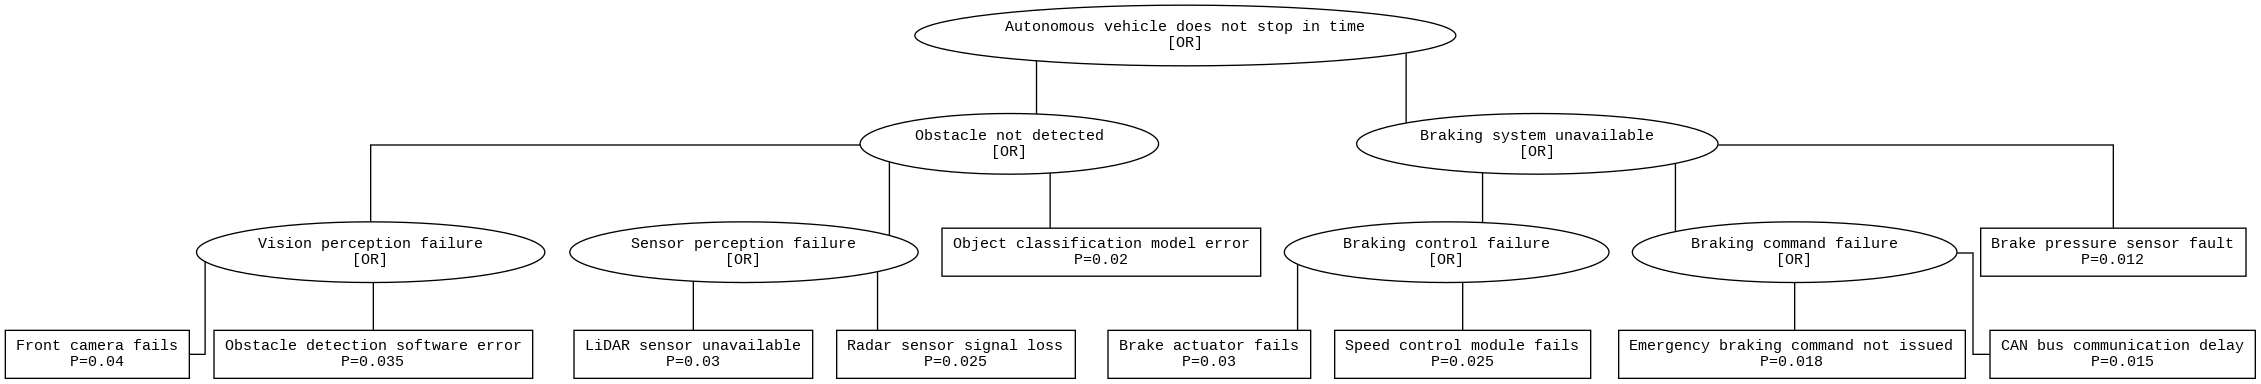


1. Probability Table


,Node,Type,Probability
0,Autonomous vehicle does not stop in time,OR,0.22396
1,Obstacle not detected,OR,0.14138
2,Vision perception failure,OR,0.0736
3,Front camera fails,BASIC,0.04
4,Obstacle detection software error,BASIC,0.035
5,Sensor perception failure,OR,0.05425
6,LiDAR sensor unavailable,BASIC,0.03
7,Radar sensor signal loss,BASIC,0.025
8,Object classification model error,BASIC,0.02
9,Braking system unavailable,OR,0.09618



2. Gate-by-Gate Analysis


,Gate,Type,Inputs,Input Probabilities,Output
0,Autonomous vehicle does not stop in time,OR,Obstacle not detected | Braking system unavail...,0.14138 | 0.09618,0.22396
1,Obstacle not detected,OR,Vision perception failure | Sensor perception ...,0.0736 | 0.05425 | 0.02,0.14138
2,Vision perception failure,OR,Front camera fails | Obstacle detection softwa...,0.04 | 0.035,0.0736
3,Sensor perception failure,OR,LiDAR sensor unavailable | Radar sensor signal...,0.03 | 0.025,0.05425
4,Braking system unavailable,OR,Braking control failure | Braking command fail...,0.05425 | 0.03273 | 0.012,0.09618
5,Braking control failure,OR,Brake actuator fails | Speed control module fails,0.03 | 0.025,0.05425
6,Braking command failure,OR,Emergency braking command not issued | CAN bus...,0.018 | 0.015,0.03273



3. MOCUS Minimal Cut Sets


,ID,Cut Set,Order
0,MCS-1,Brake actuator fails,1
1,MCS-2,Brake pressure sensor fault,1
2,MCS-3,CAN bus communication delay,1
3,MCS-4,Emergency braking command not issued,1
4,MCS-5,Front camera fails,1
5,MCS-6,LiDAR sensor unavailable,1
6,MCS-7,Object classification model error,1
7,MCS-8,Obstacle detection software error,1
8,MCS-9,Radar sensor signal loss,1
9,MCS-10,Speed control module fails,1



4. MICSUP Minimal Cut Sets


,ID,Cut Set,Order
0,MCS-1,Brake actuator fails,1
1,MCS-2,Brake pressure sensor fault,1
2,MCS-3,CAN bus communication delay,1
3,MCS-4,Emergency braking command not issued,1
4,MCS-5,Front camera fails,1
5,MCS-6,LiDAR sensor unavailable,1
6,MCS-7,Object classification model error,1
7,MCS-8,Obstacle detection software error,1
8,MCS-9,Radar sensor signal loss,1
9,MCS-10,Speed control module fails,1



MOCUS and MICSUP match: True


In [8]:
# Create FTA object using the top event
fta = FTA(TOP)

# Evaluate top event probability
top_probability, _ = fta.evaluate()

# Print heading line
print("=" * 80)

# Print analysis title
print("AUTONOMOUS VEHICLE FAULT TREE ANALYSIS")

# Print heading line
print("=" * 80)

# Print top event probability
print("Top Event Probability:", fmt(top_probability))

# Draw and display the fault tree diagram
fta.draw()

# Display probability table
print("\n1. Probability Table")
display(fta.probability_table())

# Display gate-by-gate analysis table
print("\n2. Gate-by-Gate Analysis")
display(fta.gate_analysis())

# Generate MOCUS minimal cut sets
mocus = fta.cutsets()

# Generate MICSUP minimal cut sets
micsup = fta.cutsets()

# Display MOCUS minimal cut set table
print("\n3. MOCUS Minimal Cut Sets")
display(fta.cutset_table(mocus))

# Display MICSUP minimal cut set table
print("\n4. MICSUP Minimal Cut Sets")
display(fta.cutset_table(micsup))

# Compare MOCUS and MICSUP results
print("\nMOCUS and MICSUP match:", sorted(map(sorted, mocus)) == sorted(map(sorted, micsup)))